C 129.49517365523704 L 370.0216209899092 U 291.247317584214 Upr 169.18628786045284
RUC 305.33214560220205 RCL -604.0614918020843 RC [0.0, 69.93057899202333]
129.49517365523704 291.247317584214 370.0216209899092 169.18628786045284 289.1085609247848
0.6193897032181166 11.88865803962798 Upr o -83.21102542556122 59.87095735585805 -77.81942527614622 90.0 5.391600149414989
0.0
To 5.391600149414989


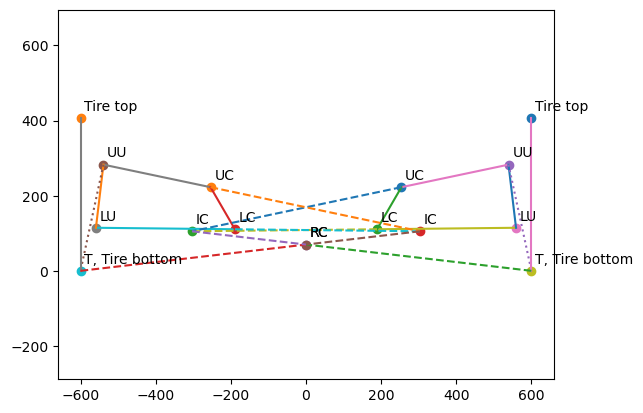

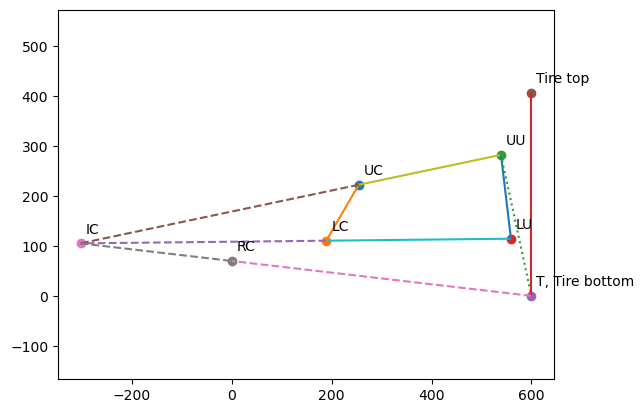

[0.0, 69.93057899202333]
done heave
done roll
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
C 110.46379497373789 L 370.22830793984406 U 311.1370276903731 Upr 169.18628786045284
RUC 151.31237765617107 RCL -603.9452157924569 RC [0.0, 68.91896457867965]
110.46379497373789 311.1370276903731 370.22830793984406 169.18628786045284 283.5227680451784
2.0122671952654203 15.376251248826192 Upr o -83.21102542556122 63.087003022256326 -80.45794348717148 90.00000000000001 2.753081938389748
0.0
To 2.753081938389748


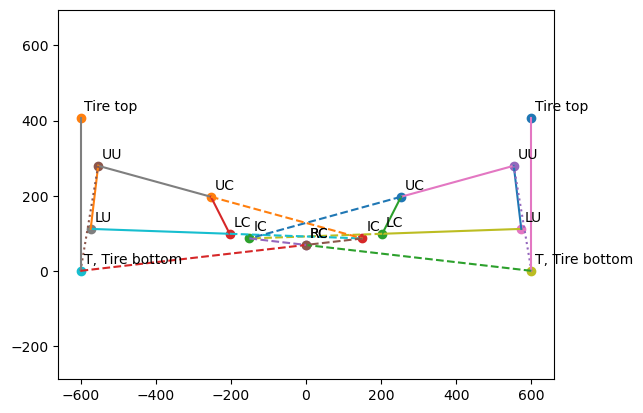

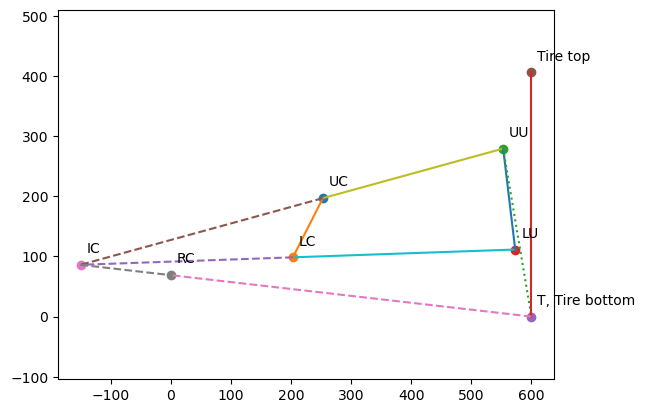

[0.0, 68.91896457867965]
done heave
done roll
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61


In [93]:
# === IMPORTS AND SETUP ===
#%matplotlib qt
#%matplotlib qt
import numpy as np
from scipy.optimize import fsolve
from numpy import sin, cos, pi, arctan
import matplotlib.pyplot as plt
from matplotlib import animation

# === VEHICLE CONFIGURATION ===
# Coordinate system: X+ front, Y+ driver side, Z+ up (roof)
# Chassis and upright hardpoints in mm (Y/Z plane), measured at mid-travel

# Mode definitions:
# mode 0 = fixed track width
# mode 1 = roll center fixed during roll
# mode 2 = roll center free to move
mode = 1
#front= True
#front= False
# === SAMPLING FOR MOTION ANALYSIS ===
steps = 61                  # Number of evaluation points
plotrange = 60              # Range of vertical motion (mm)
stepsize = plotrange / (steps - 1)  # mm per step
angle = 3 / 180 * pi     # Total roll angle in radians
stepang = angle / (steps - 1)  # radians per step
gamma=[]
RCy= []
camber= [-1 * np.pi/180, -1* np.pi/180]

for front in range(2):
    #calculator works by using these hardpoints in calculations, only change these to change the suspension then click run all
    #calculator works by using these hardpoints in calculations, only change these to change the suspension then click run all
    if front == T:
        # === HARDPOINTS (Y,Z coordinates) ===
        UCy = 250
        UCz = 210
        UC = [UCy, UCz]  # Upper chassis points
        
        LCy = 180
        LCz = 120
        LC = [LCy, LCz]  # Lower chassis points
        
        UUy = 540
        UUz = 300
        UU = [UUy, UUz]  # Upper upright points
        
        LUy = 550
        LUz = 130
        LU = [LUy, LUz]  # Lower upright points
    else:
        UCy = 240 
        UCz = 210
        UC = [UCy, UCz]  # Upper chassis points
        
        LCy = 200
        LCz = 120
        LC = [LCy, LCz]  # Lower chassis points
        
        UUy = 550
        UUz = 290
        UU = [UUy, UUz]  # Upper upright points
        
        LUy = 570
        LUz = 130
        LU = [LUy, LUz]  # Lower upright points
    
    # === CONTROL ARM LENGTHS ===
    C = ((UCy - LCy)**2 + (UCz - LCz)**2)**0.5  # Chassis vertical span
    L = ((LUy - LCy)**2 + (LUz - LCz)**2)**0.5  # Lower control arm
    U = ((UUy - UCy)**2 + (UUz - UCz)**2)**0.5  # Upper control arm
    Upr = ((UUy - LUy)**2 + (UUz - LUz)**2)**0.5  # Upright
    Ctop = 2 * UCy  # Reference for roll simulation
    Cbot = 2 * LCy
    
    print("C", C, "L", L, "U", U, "Upr", Upr)
    
    # === TIRE AND TRACK MEASUREMENTS ===
    TD = 406.4         # Tire diameter in mm (16 inches)
    TR = TD / 2        # Tire radius
    Track = 600        # Half track width (1 side of the car)
    TCz = 220.6 - 17.4  # Tire center Z coordinate
    Tz = TCz - TR      # Tire bottom contact patch Z coordinate
    TUU = ((Track - UUy)**2 + (Tz - UUz)**2)**0.5  # Length from upper upright to tire patch
    TUC = ((Track - UCy)**2 + (Tz - UCz)**2)**0.5  # Length from upper chassis to tire patch
    T = [Track, Tz]    # Tire contact patch location
    
    # === ANGLE DEFINITIONS ===
    LLCo = arctan((LUz - LCz) / (LUy - LCy))        # Lower control arm
    UUCo = arctan((UUz - UCz) / (UUy - UCy))        # Upper control arm
    UprUUo = arctan((LUz - UUz) / (LUy - UUy))      # Upright
    CLCo = arctan((UCz - LCz) / (UCy - LCy))        # Chassis reference
    TUUo = arctan((Tz - UUz) / (Track - UUy))       # Tire to upper upright
    TUCo = arctan((Tz - UCz) / (Track - UCy))       # Tire to upper chassis
    
    To = TUUo - UprUUo         # Relative upright-to-tire angle
    T90 = pi/2 - TUUo          # Perpendicular direction to tire contact
    TDo = TUUo + T90           # Tire top offset direction
    TDD = [T[0] + TD * cos(TDo), T[1] + TD * sin(TDo)]  # Tire top coordinates
    
    # === INSTANT CENTER ANALYSIS ===
    def ICloop(guess):
        ICL, ICU = guess
        loop = np.zeros(2)
        loop[0] = LC[0] - ICL * cos(LLCo) + ICU * cos(UUCo) - UC[0]
        loop[1] = LC[1] - ICL * sin(LLCo) + ICU * sin(UUCo) - UC[1]
        return loop
    
    guess = [0, 0]
    (ICL, ICU) = fsolve(ICloop, guess)  # Solve for IC link distances
    IC = [LC[0] - ICL * cos(LLCo), LC[1] - ICL * sin(LLCo)]  # IC coordinates
    
    # === ROLL CENTER CALCULATION ===
    TRo = arctan((Tz - IC[1]) / (Track - IC[0]))  # Angle from IC to tire patch
    
    def RCloop(guess):
        RCL, RCU, XXX = guess
        loop = np.zeros(3)
        loop[0] = T[0] + RCL * cos(TRo) - RCU * cos(TRo) - IC[0]
        loop[1] = T[1] + RCL * sin(TRo) - RCU * sin(TRo) - IC[1]
        loop[2] = T[0] + RCL * cos(TRo)  # Symmetry constraint (forces geometry to resolve in one plane)
        return loop
    
    guess = [0, 0, 0]
    (RCL, RCU, XXX) = fsolve(RCloop, guess)
    RC = [T[0] + RCL * cos(TRo), T[1] + RCL * sin(TRo)]  # Roll center coordinates
    
    print("RUC", RCU, "RCL", RCL, "RC", RC)
    
    # === SUMMARY OF GEOMETRY ===
    print(C, U, L, Upr, TUU)
    print(
        LLCo * 360 / (2 * pi), UUCo * 360 / (2 * pi),
        "Upr o", UprUUo * 360 / (2 * pi),
        CLCo * 360 / (2 * pi), TUUo * 360 / (2 * pi),
        TDo * 360 / (2 * pi), To * 360 / (2 * pi)
    )
    print(Tz)  # Z-height of tire bottom (should be ~0)
    print("To", To*180/pi)
    # === VISUALIZATION: SYMMETRIC VIEW ===
    fig, ax = plt.subplots()
    for name, point in zip(['UC','LC','UU','LU','T, Tire bottom', 'Tire top',"IC","RC"], [UC, LC, UU, LU, T, TDD, IC, RC]):
        ax.text(point[0]+10, point[1]+20, name)
        ax.plot(point[0], point[1], "o")
        ax.text(-point[0]+10, point[1]+20, name)   # Mirror image (left side)
        ax.plot(-point[0], point[1], "o")
    
    # Draw lines for all components
    for start, R, O, style in zip(
        [UC, LC, UU, LC, UU, T, LC, UC, T, IC],   # Starting points
        [U, L, Upr, C, TUU, TD, ICL, ICU, RCL, RCU],  # Lengths
        [UUCo, LLCo, UprUUo, CLCo, TUUo, TDo, LLCo + pi, UUCo + pi, TRo, TRo],  # Angles
        ('-', '-', '-', '-', ':', '-', '--', '--', '--', '--')  # Line styles
    ):
        ax.plot([start[0], start[0] + R * cos(O)], [start[1], start[1] + R * sin(O)], style)
        ax.plot([-start[0], -start[0] - R * cos(O)], [start[1], start[1] + R * sin(O)], style)  # Symmetric side
    
    plt.axis('equal')
    plt.show()
    
    # === VISUALIZATION: DRIVER-SIDE ONLY ===
    fig, ax = plt.subplots()
    for name, point in zip(['UC','LC','UU','LU','T, Tire bottom', 'Tire top',"IC","RC"], [UC, LC, UU, LU, T, TDD, IC, RC]):
        ax.text(point[0]+10, point[1]+20, name)
        ax.plot(point[0], point[1], "o")
    
    for start, R, O, style in zip(
        [UC, LC, UU, LC, UU, T, LC, UC, T, IC],
        [U, L, Upr, C, TUU, TD, ICL, ICU, RCL, RCU],
        [UUCo, LLCo, UprUUo, CLCo, TUUo, TDo, LLCo + pi, UUCo + pi, TRo, TRo],
        ('-', '-', '-', '-', ':', '-', '--', '--', '--', '--')
    ):
        ax.plot([start[0], start[0] + R * cos(O)], [start[1], start[1] + R * sin(O)], style)
    
    plt.axis('equal')
    plt.show()

    print(RC)
    
    RCy.append(RC[1])
    
    
    
    
    
    
    
    # Import necessary libraries
    import numpy as np
    from scipy.optimize import fsolve
    from numpy import sin, cos, pi, arctan
    import matplotlib.pyplot as plt
    from matplotlib import animation
    from scipy.optimize import least_squares
    
    # Known suspension geometry parameters 
    knowns = (U, L, C, Upr, T, CLCo, To, TUU, TUC, TUCo)
    
    # Initialize heave motion arrays
    MM = np.zeros((steps))      # Vertical motion (mm input) per step
    LLCO = np.zeros((steps))    # Lower control arm angle
    UUCO = np.zeros((steps))    # Upper control arm angle
    UprUUO = np.zeros((steps))  # Upper upright angle
    ICL = np.zeros((steps))     # Instant center length from lower arm
    ICU = np.zeros((steps))     # Instant center length from upper arm
    IC = np.zeros((steps,2))    # Instant center coordinates
    # Roll center maps for right/left arms (over all motion range)
    RRCL, RRCU, LRCL, LRCU = np.zeros((steps,steps)), np.zeros((steps,steps)), np.zeros((steps,steps)), np.zeros((steps,steps))
    RC = np.zeros((steps,steps,2))  # Roll center location map (Y,Z)
    
    # Initial guess for angle solving (fsolve)
    guessinput = (LLCo, UUCo, UprUUo)
    
    # Solve instant center from vector loop closure
    def ICloop(guess1):
        ICL, ICU = guess1
        loop = np.zeros(2)
        loop[0] = LC[0] - ICL * cos(LLCO[i]) + ICU * cos(UUCO[i]) - UC[0]
        loop[1] = LC[1] - ICL * sin(LLCO[i]) + ICU * sin(UUCO[i]) - UC[1]
        return loop
    
    # Solve 3-vector loop: LC + L + U + Upr + TUC = known chassis coordinates
    def positionloop(guessinput, MM_i, knowns):
        (LLCo, UUCo, UprUUo) = guessinput
        (U, L, C, Upr, T, CLCo, To, TUU, TUC, TUCo) = knowns
        
        try:
            loop = np.zeros(3)
            loop[0] = C*cos(CLCo) + U*cos(UUCo) + Upr*cos(UprUUo) - L*cos(LLCo)
            loop[1] = C*sin(CLCo) + U*sin(UUCo) + Upr*sin(UprUUo) - L*sin(LLCo)
            loop[2] = U*sin(UUCo) + TUU*sin(UprUUo + To) - MM_i - TUC*sin(TUCo)
        except Exception as e:
            print("Math error in positionloop:", e)
            loop = [np.nan, np.nan, np.nan]
        return loop
    
    # Solve geometry at each vertical motion (heave) position
    Guess = np.array([LLCo, UUCo, UprUUo])
    guess1 = [0, 0]
    
    for i in range(steps):
        MM[i] = i * stepsize - 20  # Vertical input sweep, centered at -20 mm
        
        # Solve upper/lower/upright angles that satisfy geometry
        (LLCO[i], UUCO[i], UprUUO[i]) = fsolve(positionloop, Guess, args=(MM[i], knowns))
        Guess = (LLCO[i], UUCO[i], UprUUO[i])
        
        # Solve instant center lengths for given configuration
        (ICL[i], ICU[i]) = fsolve(ICloop, guess1)
        guess1 = [ICL[i], ICU[i]]
        
        # Compute IC coordinates
        IC[i] = LC[0] - ICL[i] * cos(LLCO[i]), LC[1] - ICL[i] * sin(LLCO[i])
    
    # Compute roll centers across all combinations of left/right travel
    T = np.zeros((steps, 2))     # Tire contact point
    TRo = np.zeros((steps))      # Tire to IC angle (right)
    CTRo = np.zeros((steps))     # cos(TRo)
    STRo = np.zeros((steps))     # sin(TRo)
    
    for i in range(steps):
        T[i] = [UC[0] + U*cos(UUCO[i]) + TUU*cos(UprUUO[i] + To),
                UC[1] + U*sin(UUCO[i]) + TUU*sin(UprUUO[i] + To)]
        
        TRo[i] = arctan((T[i][1] - IC[i][1]) / (T[i][0] - IC[i][0]))
        CTRo[i] = cos(TRo[i])
        STRo[i] = sin(TRo[i])
    
    # Closure equation for roll center geometry solving
    def RCloop(guess2):
        rRCL, rRCU, lRCL, lRCU, xxx, yyy = guess2
        loop = np.zeros(6)
        loop[0] = T[r][0] + rRCL*CTRo[r] - rRCU*CTRo[r] - IC[r][0]
        loop[1] = T[r][1] + rRCL*STRo[r] - rRCU*STRo[r] - IC[r][1]
        loop[2] = -T[l][0] + lRCL*CTRo[l] - lRCU*CTRo[l] + IC[l][0]
        loop[3] = T[l][1] + lRCL*(-STRo[l]) - lRCU*(-STRo[l]) - IC[l][1]
        loop[4] = T[r][0] + rRCL*CTRo[r] - lRCU*CTRo[l] + IC[l][0]
        loop[5] = T[r][1] + rRCL*STRo[r] - lRCU*(-STRo[l]) - IC[l][1]
        return loop
    
    # Loop over all heave pairings and solve roll center location
    for l in range(steps):
        for r in range(steps):
            if r >= l:
                guess2 = [0, 0, 0, 0, 0, 0]
                xxx = yyy = 0
                (RRCL[r][l], RRCU[r][l], LRCL[r][l], LRCU[r][l], xxx, yyy) = fsolve(RCloop, guess2)
                RC[r][l][0] = T[r][0] + RRCL[r][l] * cos(TRo[r])
                RC[r][l][1] = T[r][1] + RRCL[r][l] * sin(TRo[r])
            else:
                RC[r][l][0] = -RC[l][r][0]  # symmetry exploitation
                RC[r][l][1] = RC[l][r][1]
                RRCL[r][l], RRCU[r][l], LRCL[r][l], LRCU[r][l] = RRCL[l][r], RRCU[l][r], LRCL[l][r], LRCU[l][r]
    
    print("done heave")
    
    # Initialize roll variables
    A = np.zeros((steps))        # Roll angle input (in radians)
    LLCOA = np.zeros((steps))    # LCA angle - left
    LLCOB = np.zeros((steps))    # LCA angle - right
    UUCOA = np.zeros((steps))    # UCA angle - left
    UUCOB = np.zeros((steps))    # UCA angle - right
    UprUUOA = np.zeros((steps))  # Upright angle - left
    UprUUOB = np.zeros((steps))  # Upright angle - right
    
    # Instant center lengths
    ICLA = np.zeros((steps))
    ICUA = np.zeros((steps))
    ICLB = np.zeros((steps))
    ICUB = np.zeros((steps))
    
    # Roll center arm vectors
    RCLA = np.zeros((steps))
    RCUA = np.zeros((steps))
    RCLB = np.zeros((steps))
    RCUB = np.zeros((steps))
    Track = np.zeros((steps))   # Track width during roll
    
    # Coordinates of suspension points
    UCA = np.zeros((steps,2))
    UCB = np.zeros((steps,2))
    LCA = np.zeros((steps,2))
    LCB = np.zeros((steps,2))
    ICA = np.zeros((steps,2))
    ICB = np.zeros((steps,2))
    
    # Tire-to-IC angles
    TROA = np.zeros((steps))
    TROB = np.zeros((steps))
    
    # Final roll center coordinates across all roll states
    RCroll = np.zeros((steps,2))
    
    # Assign all knowns for fsolve loop
    knowns = (U, L, C, Ctop, Cbot, Upr, CLCo, To, TUU, TUC, TUCo)
    
    # Closure equation for roll configuration solving
    def Rollloop(guessinput, a, knowns):
        # Unpack current guess and known values
        (LLCoa, LLCob, UUCoa, UUCob, UprUUoa, UprUUob, track, xxx, xxx1, xxx2, xxx3) = guessinput
        (U, L, C, Ctop, Cbot, Upr, CLCo, To, TUU, TUC, TUCo) = knowns
    
        # Lock track width if mode==0
        if mode == 0:
            track = 1200
    
        # Construct all control arm and upright vectors based on geometry
        UCa = [track/2 - (-TUU*cos(pi - UprUUoa - To) - U*cos(pi - UUCoa)),
               -TUU*sin(pi - UprUUoa - To) - U*sin(pi - UUCoa)]
        
        UCb = [track/2 + (-U*cos(UUCob) - TUU*cos(UprUUob + To)),
               -U*sin(UUCob) - TUU*sin(UprUUob + To)]
    
        LCa = [track/2 - (-TUU*cos(pi - UprUUoa - To) + Upr*cos(pi - UprUUoa) - L*cos(pi - LLCoa)),
               -TUU*sin(pi - UprUUoa - To) + Upr*sin(pi - UprUUoa) - L*sin(pi - LLCoa)]
    
        LCb = [track/2 + (-L*cos(LLCob) + Upr*cos(UprUUob) - TUU*cos(UprUUob + To)),
               -L*sin(LLCob) + Upr*sin(UprUUob) - TUU*sin(UprUUob + To)]
    
        # Vector loop constraints (position closure equations)
        loop = np.zeros(11)
        loop[0] = UCa[1] + Ctop*sin(a) - UCb[1]
        loop[1] = -UCa[0] + Ctop*cos(a) - UCb[0]
        loop[2] = LCa[1] + Cbot*sin(a) - LCb[1]
        loop[3] = -LCa[0] + Cbot*cos(a) - LCb[0]
        loop[4] = LCa[0] + C*cos(CLCo - a) - UCa[0]
        loop[5] = LCa[1] + C*sin(CLCo - a) - UCa[1]
        loop[6] = LCb[0] + C*cos(CLCo + a) - UCb[0]
        loop[7] = LCb[1] + C*sin(CLCo + a) - UCb[1]
        loop[8] = C*sin(CLCo + a) + Ctop*sin(a) - Cbot*sin(a) - C*sin(pi - CLCo + a)
        loop[9] = C*cos(CLCo + a) + Ctop*cos(a) - Cbot*cos(a) - C*cos(pi - CLCo + a)
    
        # Instant center solving via direct matrix solve
        ICar = [[-cos(LLCoa), cos(UUCoa), 0, 0],
                [-sin(LLCoa), sin(UUCoa), 0, 0],
                [0, 0, -cos(LLCob), cos(UUCob)],
                [0, 0, -sin(LLCob), sin(UUCob)]]
    
        ICve = [[UCa[0] - LCa[0]],
                [UCa[1] - LCa[1]],
                [UCb[0] - LCb[0]],
                [UCb[1] - LCb[1]]]
    
        # Solve for arm lengths from joint to IC
        [ICLA[i], ICUA[i], ICLB[i], ICUB[i]] = np.linalg.solve(ICar, np.squeeze(ICve))
    
        # Use arm angles and lengths to get IC coordinates
        ICa = [LCa[0] - ICLA[i]*cos(LLCoa), LCa[1] - ICLA[i]*sin(LLCoa)]
        ICb = [LCb[0] - ICLB[i]*cos(LLCob), LCb[1] - ICLB[i]*sin(LLCob)]
    
        # Compute tire-to-IC angles (roll axis projection)
        TRoa = arctan((-ICa[1]) / (track/2 - ICa[0]))
        TRob = arctan((-ICb[1]) / (track/2 - ICb[0]))
    
        # Set up matrix for solving roll center locations
        RCar = [[cos(TRoa), -cos(TRoa), 0, 0],
                [sin(TRoa), -sin(TRoa), 0, 0],
                [0, 0, cos(TRob), -cos(TRob)],
                [0, 0, sin(TRob), -sin(TRob)],
                [0, -cos(pi - TRoa), cos(TRob), 0],
                [0, -sin(pi - TRoa), sin(TRob), 0]]
    
        RCve = [[ICa[0] - track/2],
                [ICa[1]],
                [ICb[0] - track/2],
                [ICb[1]],
                [-ICa[0] - track/2],
                [ICa[1]]]
    
        # Solve least squares for roll center arm lengths
        [RCLA[i], RCUA[i], RCLB[i], RCUB[i]] = np.linalg.lstsq(RCar, np.squeeze(RCve), rcond=None)[0]
    
        # Compute roll center global coordinate
        RCroll[i] = [track/2 + RCLB[i]*cos(TRob), RCLB[i]*sin(TRob)]
    
        # Final constraint used to pin roll center movement during mode-based sweep
        switch = [track - 1200, RCroll[i][1] - RC[int((steps-1)/3)][int((steps-1)/3)][1], 0]
        loop[10] = switch[mode]
    
        return loop
    
    # Initial guess for roll sweep
    guess3 = [LLCo, LLCo, UUCo, UUCo, UprUUo, UprUUo, 1200, 0, 0, 0, 0]
    
    # Roll sweep loop — iterate over roll angles to find geometry that satisfies all loops
    for i in range(steps):
        A[i] = i * stepang  # Angle of body roll
    
        # Solve full position + IC + roll center equations
        sol, info, ier, msg = fsolve(Rollloop, guess3, args=(A[i], knowns), full_output=True)
    
        # Store result and feed forward to next guess
        (LLCOA[i], LLCOB[i], UUCOA[i], UUCOB[i], UprUUOA[i], UprUUOB[i], Track[i], xxx, xxx1, xxx2, xxx3) = sol
        guess3 = [LLCOA[i], LLCOB[i], UUCOA[i], UUCOB[i], UprUUOA[i], UprUUOB[i], Track[i], 0, 0, 0, 0]
    
        # Lock track if needed
        if mode == 0:
            Track[i] = 1200
    
        # Recompute physical coordinates of arms and ICs
        UCA[i] = [Track[i]/2 - (-TUU * cos(pi - UprUUOA[i] - To) - U * cos(pi - UUCOA[i])),
                  -TUU * sin(pi - UprUUOA[i] - To) - U * sin(pi - UUCOA[i])]
    
        UCB[i] = [Track[i]/2 + (-U * cos(UUCOB[i]) - TUU * cos(UprUUOB[i] + To)),
                  -U * sin(UUCOB[i]) - TUU * sin(UprUUOB[i] + To)]
    
        LCA[i] = [Track[i]/2 - (-TUU * cos(pi - UprUUOA[i] - To) + Upr * cos(pi - UprUUOA[i]) - L * cos(pi - LLCOA[i])),
                  -TUU * sin(pi - UprUUOA[i] - To) + Upr * sin(pi - UprUUOA[i]) - L * sin(pi - LLCOA[i])]
    
        LCB[i] = [Track[i]/2 + (-L * cos(LLCOB[i]) + Upr * cos(UprUUOB[i]) - TUU * cos(UprUUOB[i] + To)),
                  -L * sin(LLCOB[i]) + Upr * sin(UprUUOB[i]) - TUU * sin(UprUUOB[i] + To)]
    
        # Instant center coordinates
        ICA[i] = [LCA[i, 0] - ICLA[i] * cos(LLCOA[i]), LCA[i, 1] - ICLA[i] * sin(LLCOA[i])]
        ICB[i] = [LCB[i, 0] - ICLB[i] * cos(LLCOB[i]), LCB[i, 1] - ICLB[i] * sin(LLCOB[i])]
    
        # Tire-to-IC angles
        TROA[i] = arctan((-ICA[i, 1]) / (Track[i]/2 - ICA[i, 0]))
        TROB[i] = arctan((-ICB[i, 1]) / (Track[i]/2 - ICB[i, 0]))
    
    print("done roll")
    gamma1, gamma2= [],[]
    for i in range(steps):
        gamma1.append(-((UprUUOA[i]+To+T90)-pi/2)+camber[front])
        gamma2.append(+((UprUUOB[i]+To+T90)-pi/2)-camber[front])
    gamma.append(gamma1)
    gamma.append(gamma2)















In [ ]:
#print(RCy)
#print(gamma)

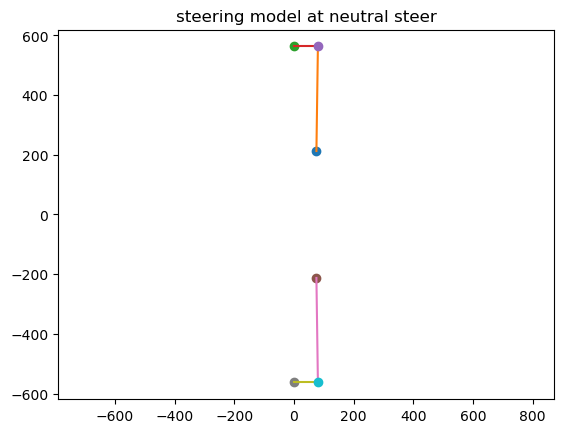

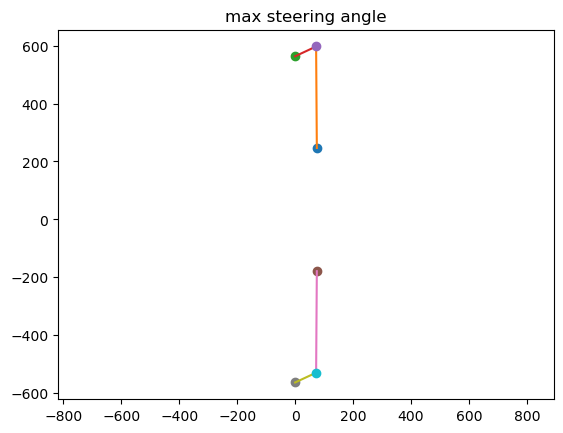

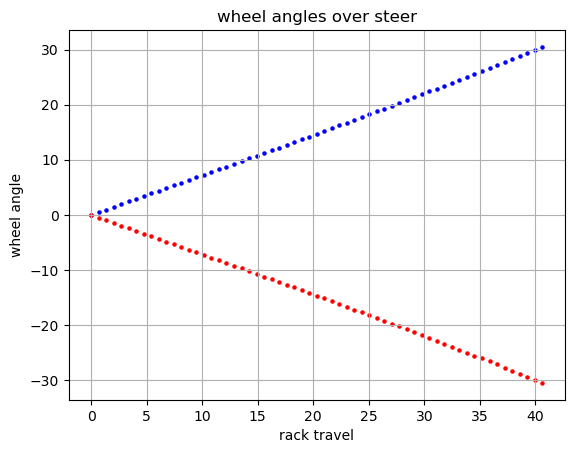

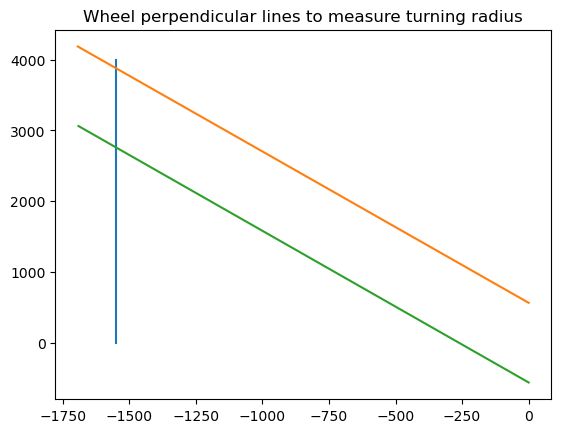

ackerman angle: 0.0
front wheels intersection radius top calculated in x,y [-273180.7783517789, 585365.8477216812]
front wheels intersection radius bottom calculated in x,y [-273180.77835177886, 585365.8477216812]


In [97]:
#steering---------------

#variable inputs
ep= 1e-6

rackx = 75 #rack position
racky = 425.4
racky2= racky/2

pivoty = (553+573)/2 #pivot of the upright
pivotx = 0

ackx= 80 #tie rod connector point
ackang = 0*np.pi/180 #33 is what ive found 100% ackerman
acky= ackx * np.tan(ackang)

#print(pivoty +acky)
tie= ((-rackx+ackx)**2 + (-racky2 +acky +pivoty)**2)**(1/2)

dist= 82.55/2 #travel of rack

tieang = np.arctan2(-(-racky2 +acky),(-rackx+ackx))
ack= ((pivotx-ackx)**2 + (acky)**2)**(1/2)

wheelbase= 1550
track = 1200
CGx= .5 #percent away from front
stepPer=.3


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

#plot 1 is nuetral steer, 
#plot 2 is full steer to the left, 
#plot 3 is the wheel angles, 
#plot 4 isfinding where the tires will intersect

#print(tie, ack)
#print(tieang*180/np.pi,ackang*180/np.pi) 
plt.plot(rackx, racky2, "o")
plt.plot([rackx,pivotx+ackx], [racky2,pivoty +acky], "-")
plt.plot(pivotx, pivoty, "o")
plt.plot([pivotx,pivotx+ackx], [pivoty,pivoty +acky], "-")
plt.plot(pivotx+ackx, pivoty +acky, "o")

plt.plot(rackx, -racky2, "o")
plt.plot([rackx,pivotx+ackx], [-racky2,-pivoty -acky], "-")
plt.plot(pivotx, -pivoty, "o")
plt.plot([pivotx,pivotx+ackx], [-pivoty,-pivoty -acky], "-")
plt.plot(pivotx+ackx, -pivoty -acky, "o")
plt.axis('equal')

plt.title("steering model at neutral steer")
plt.show()

#print(ackang/np.pi*180)
steps=steps
MM = np.empty([2,steps])
Tieang= np.empty([2,steps])
ang = np.empty([2,steps])

for n in range(2):
    
    guess= [tieang, 0]
    def ackerman(guess,mm):
        (TieAng, Ang) = guess
        loop = np.empty(2)
        loop[0]= mm +racky2 + np.sin(TieAng)*tie - np.sin(Ang+ackang)*ack -pivoty
        loop[1]= rackx + np.cos(TieAng)*tie - np.cos(Ang+ackang)*ack -pivotx
        return loop

    for i in range(steps):
        MM[n,i]= (-1)**n * i *dist/steps
        #print(MM[n,i])
        (Tieang[n,i], ang[n,i]) = fsolve(ackerman, guess, args=(MM[n,i]))
        guess = (Tieang[n,i], ang[n,i])
        #print(Tieang[n,i]/np.pi*180,ang[n,i]/np.pi*180)
    #print("\n")
    
for n in range(2):
    i=50
    plt.plot(rackx, (-1)**n *(racky2 +MM[n,i]), "o")
    plt.plot([rackx,pivotx+ack*np.cos(ang[n,i]+ackang)], [(-1)**n *(racky2 +MM[n,i]),(-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang))], "-")
    plt.plot(pivotx, (-1)**n *pivoty, "o")
    plt.plot([pivotx,pivotx+ack*np.cos(ang[n,i]+ackang)], [(-1)**n *(pivoty),(-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang))], "-")
    plt.plot(pivotx+ack*np.cos(ang[n,i]+ackang), (-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang)), "o")
plt.axis('equal')

plt.title("max steering angle")
plt.show()

fig, ax = plt.subplots()
for n in range(2):
    col= ["blue","red"]
    for i in range(steps):
        ax.scatter(MM[0,i],ang[n,i]/np.pi*180, s=5, color=col[n])
plt.xlabel("rack travel")
plt.ylabel("wheel angle")
ax.set_title("wheel angles over steer")
plt.grid(True)
plt.show()

i=50
x=4000
#print(ang[0,i])
plt.plot([-1*wheelbase,-1*wheelbase],[0,x],"-")
plt.plot([pivotx,pivotx+x*np.cos(ang[0,i]+np.pi/2)],[pivoty,pivoty+x*np.sin(ang[0,i]+np.pi/2)],"-")
plt.plot([pivotx,pivotx-x*np.cos(ang[1,i]+np.pi/2)],[-pivoty,-pivoty+x*np.sin(ang[1,i]+np.pi/2)],"-")
#plt.axis('equal')

plt.title("Wheel perpendicular lines to measure turning radius")
plt.show()

A= [[np.cos(ang[0,i]+np.pi/2),np.cos(-ang[1,i]+np.pi/2)],
    [np.sin(ang[0,i]+np.pi/2),np.sin(ang[1,i]+np.pi/2)]]
a=[0, -pivoty*2]
#print(A)
b=np.linalg.solve(A,a)
print("ackerman angle:",ackang*180/np.pi)
print("front wheels intersection radius top calculated in x,y",[b[0]*np.cos(ang[0,i]+np.pi/2),b[0]*np.sin(ang[0,i]+np.pi/2)+pivoty])
print("front wheels intersection radius bottom calculated in x,y",[-b[1]*np.cos(-ang[1,i]+np.pi/2),-b[1]*np.sin(ang[1,i]+np.pi/2)-pivoty])

In [131]:
import numpy as np
import matplotlib.pyplot as plt

#optimum k found roll stifness numbers
#roll stiffness curves

heave = np.array([20,16,12,8,4,0,-4,-8,-12,-16,-20,-24,-28,-32,-36,-40,-44,-48,-52,-56,-60])
phi = 1
t= 1.200
z= phi*t/2
Kfront = np.array([
    17778.20897, 17498.31501, 17315.37518, 17135.2893, 16957.99831,
    16783.44468, 16594.53046, 16408.788, 16209.69434, 16014.20233,
    15806.38359, 15602.58409, 15387.48457, 15161.91981, 14941.27876,
    14696.99171, 14458.64711, 14212.54698, 13959.52941, 13687.66009,
    13411.27572
])

Krear = np.array([
    13439.10355,    13710.13747,    13973.71339,    14228.79017,
    14474.32128,    14709.26294,    14932.58287,    15143.26926,
    15340.34020,    15504.45560,    15652.55702,    15783.89345,
    15859.68635,    15916.88986,    15936.02649,    15897.78769,
    15802.79066,    15671.21879,    15467.75868,    15178.81683,
    14828.88469
])


coeffsF = np.polyfit(heave, Kfront, 2)  # second order polynomial fit
KfitF = np.poly1d(coeffsF)

coeffsR = np.polyfit(heave, KRear, 2)  # second order polynomial fit
KfitR = np.poly1d(coeffsR)

print(f"K(z) = {coeffsF[0]:.6f}*z² + {coeffsF[1]:.6f}*z + {coeffsF[2]:.6f}")
z=7
K = Kfit(z)
print(K)

K(z) = -0.148881*z² + 47.002290*z + 16802.282266
17124.003117807257


ackerman step: 9 left steer, right steer: 4.368015182093614 4.363366140415933 Speed: 22
weight: 181.4 1779.534

solution: 
beta: 152.83166840617014 R: 29.435508706619203 phi: 1.1590048998934472
x (scrub): [-120.77821782117289, -108.44113669399644, -5.972523312379138, 4.451129484499022] -230.74074834304943 g: -0.12966357953433283
y (lateral force): [887.6640901574357, 630.0528047848703, 855.487048369027, 637.5669755377743] 3010.7709188491076 g: 1.691887268717039
slip forces: [895.8431307182562, 639.3168361186556, 855.5078964929937, 637.5825129738681] 3028.2503763037735 g: 1.7017097601415727
mu: [1.6730540597280759, 1.7346838366834862, 1.683826796336271, 1.7351206910966233]
w [535.4537861519304, 368.5494858480696, 508.073572860604, 367.45715513939615]
cp magnitude: 86.1294456
total g: 2962.4528127492217 1.6647351569282867 1.5878816834493386


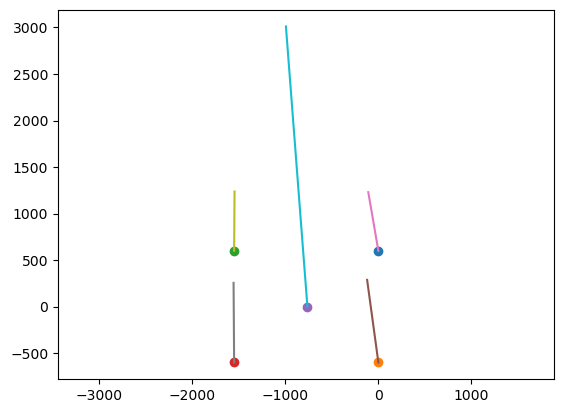

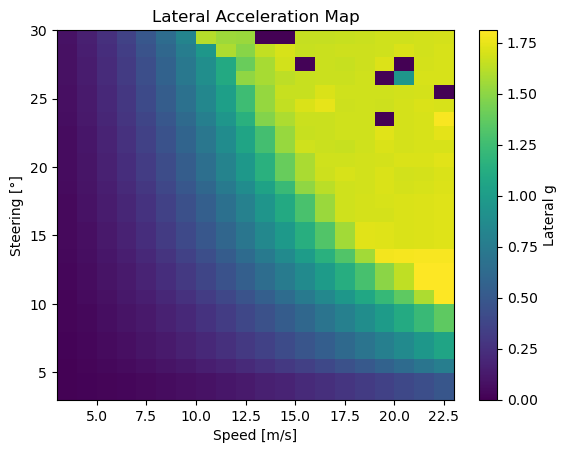

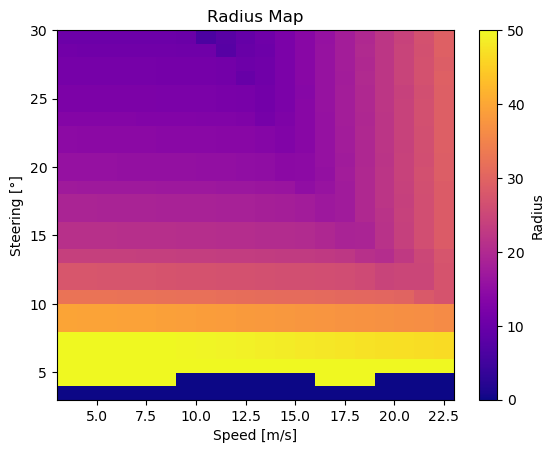

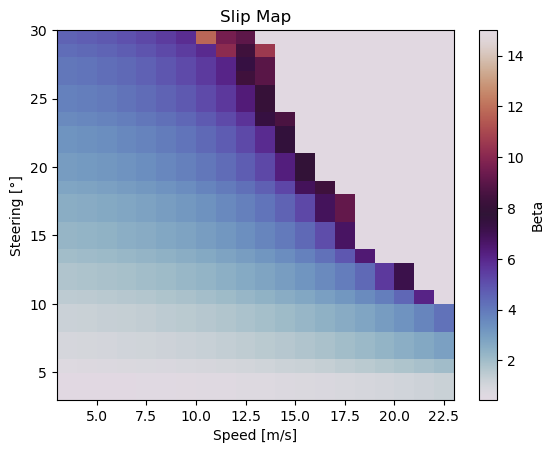

In [187]:
#4 wheel bicycle steady state magic
stepPer=.15 #how much steering

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve


wheelbase= 1550
track = 1200
CGx= 1-.508
CGy = .283
#USER INPUT NEED VALUE

#for each in [5,7.5,10,12.5,15,17.5,20,22.5,25]:
    

U= 22 #each #m/s

#tire data will be blank or fake values on publication b
B = 10.0      # stiffness
C = 1.9       # shape
D = 1.0       # peak (normalized force)
E = 0.97      # curvature

phi0=0

def magic_formula(x, B, C, D, E):
    """Single-axis Pacejka Magic Formula"""
    return D * np.sin(C * np.arctan(B * x - E * (B * x - np.arctan(B * x)))) # * np.cos(a) for moments


#FAKE PAJECAKA VALUES TO BE TCC IP COMPLIANT----


def pacejka_Fy_camber(alpha, cp, Fz, gamma, mu):
    #alpha= max(alpha, 1*np.pi/180)
    NF= abs(cp*Fz)
    B0 = 15      # stiffness
    B  = B0 * (max(NF, 1.0) / 400.0) ** -0.2
    C = 1.5       # shape
    D = 3.2*NF**.9     # peak (normalized force)
    E = 0.95
    Ksh = .05   # horizontal shift per degree camber
    Ksv = 0.2    # vertical gain per degree camber
    
    Sh = Ksh * gamma
    Sv = Ksv * NF * gamma
    
    alpha_eff = alpha + Sh
    Fy = D * np.sin(C * np.arctan(B * alpha_eff - E*(B*alpha_eff - np.arctan(B*alpha_eff)))) + Sv
    
    return Fy

def pacejka_t(alpha, cp, Fz, gamma):
    NF= cp*Fz
    B0t = 10      # stiffness
    Bt  = B0t * (max(NF, 1.0) / 400.0) ** -0.1
    Ct = 1.5       # shape
    Dt = .00007*NF**.9     # peak (normalized force)
    Et = 0.7

    Ksht = 0.005   # horizontal shift per degree camber
    Ksvt = 0.00004    # vertical gain per degree camber
    
    Sht = Ksht * gamma
    Svt = Ksvt * NF * gamma
    alpha_t = alpha + Sht
    
    t=  Dt * np.cos(Ct * np.arctan(Bt * alpha_t - Et * (Bt * alpha_t - np.arctan(Bt * alpha_t)))) +Svt
    return t
    
def pacejka_Mzr(alpha, cp, Fz, gamma, R0=1):
    NF= cp*Fz
    B0r = .1      # stiffness
    Br  = B0r * (max(NF, 1.0) / 400.0) ** 3
    Cr = 1.5       # shape
    Dr = .07* NF**.9   # peak (normalized force)
    Er = 0.95
    
    Kshr = 0.5   # horizontal shift per degree camber
    Ksvr = 0.02    # vertical gain per degree camber
    
    Shr = Kshr * gamma
    Svr = Ksvr * NF * gamma
    alpha_r = alpha + Shr
    
    Mzr= Dr * np.cos(Cr * np.arctan(Br* alpha_r - Er * (Br * alpha_r - np.arctan(Br * alpha_r)))) +Svr
    return Mzr



steerstep= int(np.round(stepPer * steps))

steer= 15 /180*np.pi #radians
steerr=ang[1,steerstep]# 15 /180*np.pi #radians #negative bc when calculatin steering the outside wheel was negative
steerl=ang[0,steerstep]# 15 /180*np.pi #radians
steer=( -steerr+steerl )/2#radians
toef= -1 /180*np.pi #radians inside is positive on each wheel
toer= 0.4 /180*np.pi #radians inside is positive on each wheel
mass= 181.4 #kg of 400lb car
mg= mass * 9.81
Cax= 38000
print("ackerman step:",steerstep, "left steer, right steer:",steerl*180/np.pi,-steerr*180/np.pi, "Speed:", U)
print("weight:", mass, mg)

wx= .05 #%
wy= .00 #%
#W= [.25+wx/2 -wy/CGx,.25+wx/2+wy/CGx,.25-wx/2-wy/(1-CGx),.25-wx/2+wy/(1-CGx)] #%
Wx= [.5+wx,.5-wx]
Wy= [.5-wy,.5+wy]
R0= (wheelbase/1000)/np.tan(steer)
#plt.plot(CG[0],R,"o")
af= Wx[0]*mass * U**2 / (Cax*  R0) *1000
ar= Wx[1]*mass * U**2 / (Cax*  R0) *1000
Fyf= Cax * af
Fyr= Cax * ar


Fy3= mass * U**2 / (R0)
#print(Fy1)

#Kf, Kr = 16783.44468, 14709.26294
#Kf, Kr = 15387.48457, 15859.68635
hrcf, hrcr =.06891896457867965, .06993057899202333
sprung= 0.9 #percent of sprung mass


#4 wheel from here-------------------------------
#print(R0)

def steady_state(vars):
    beta, k, phi = vars
    R = 1/abs(k)
    r= U/R
    global Fy3
    Fy3= mass * U**2 / (R)
    
    Uy=U*np.sin(beta)
    Ux=U*np.cos(beta)
    
    Vx=[]
    Vy=[]
    
    
    #strait line x and y velocity based on U and w at each wheel, index (0=FR, 1=FL, 2=RR, 3=RL) left hand turn
    Vx.append(Ux+r*track/2/1000) #FR outer
    Vy.append(Uy+r*wheelbase*CGx/1000)
    Vx.append(Ux-r*track/2/1000) #FL inner
    Vy.append(Uy+r*wheelbase*CGx/1000)
    Vx.append(Ux+r*track/2/1000) #RR outer
    Vy.append(Uy-r*wheelbase*(1-CGx)/1000)
    Vx.append(Ux-r*track/2/1000) #RL inner
    Vy.append(Uy-r*wheelbase*(1-CGx)/1000)
    
    V1x=[]
    #print(Vx)
    V1y=[]
    
    #changing each to the rotated frame of bearing and perpendicular velocities
    V1x.append(np.cos(-steerr + toef)*Vx[0] + np.sin(-steerr + toef)*Vy[0])  # FR
    V1y.append(-np.sin(-steerr + toef)*Vx[0] + np.cos(-steerr + toef)*Vy[0])
    V1x.append(np.cos(steerl - toef)*Vx[1] + np.sin(steerl - toef)*Vy[1])  # FL
    V1y.append(-np.sin(steerl - toef)*Vx[1] + np.cos(steerl - toef)*Vy[1])
    V1x.append(np.cos(toer)*Vx[2] + np.sin(toer)*Vy[2])  # RR
    V1y.append(-np.sin(toer)*Vx[2] + np.cos(toer)*Vy[2])
    V1x.append(np.cos(-toer)*Vx[3] + np.sin(-toer)*Vy[3])  # RL
    V1y.append(-np.sin(-toer)*Vx[3] + np.cos(-toer)*Vy[3])
    
    #print(V1x)
    #print(V1y)
    
    #weight transfer static

    heave = np.array([20,16,12,8,4,0,-4,-8,-12,-16,-20,-24,-28,-32,-36,-40,-44,-48,-52,-56,-60])
    t= 1.200
    z= -phi*track/1000/2
    Kfront = np.array([
        17778.20897, 17498.31501, 17315.37518, 17135.2893, 16957.99831,
        16783.44468, 16594.53046, 16408.788, 16209.69434, 16014.20233,
        15806.38359, 15602.58409, 15387.48457, 15161.91981, 14941.27876,
        14696.99171, 14458.64711, 14212.54698, 13959.52941, 13687.66009,
        13411.27572
    ], dtype=float)
    
    Krear = np.array([
        13439.10355,    13710.13747,    13973.71339,    14228.79017,
        14474.32128,    14709.26294,    14932.58287,    15143.26926,
        15340.34020,    15504.45560,    15652.55702,    15783.89345,
        15859.68635,    15916.88986,    15936.02649,    15897.78769,
        15802.79066,    15671.21879,    15467.75868,    15178.81683,
        14828.88469
    ], dtype=float)
    
    
    coeffsF = np.polyfit(heave, Kfront, 2)  # second order polynomial fit
    KfitF = np.poly1d(coeffsF)
    
    coeffsR = np.polyfit(heave, Krear, 2)  # second order polynomial fit
    KfitR = np.poly1d(coeffsR)
    
    #print(f"K(z) = {coeffsF[0]:.6f}*z² + {coeffsF[1]:.6f}*z + {coeffsF[2]:.6f}")
    z=7
    Kf = KfitF(z)
    Kr = KfitR(z)

    

    
    WfStatic = mg* (1-CGx) / 2
    WrStatic = mg* CGx / 2
    Latt = Fy3 * CGy / (track/1000)   # total lateral transfer [N]
    Latf = Latt * (1-CGx) /2 * (1-sprung)
    Latr = Latt * CGx /2  * (1-sprung)
    #print(Latt)
    #print(WfStatic,WrStatic,Latt,Latf,Latr)
    #weight transfer spring
    WfSprung = (Fy3 * sprung * (1-CGx) *(CGy- hrcf) / (track/1000)) * (Kf / (Kf + Kr)) / 2
    WrSprung = (Fy3 * sprung * (CGx) *(CGy- hrcr) / (track/1000)) * (Kr / (Kf + Kr)) / 2
    #print(WfStatic)
    #print(WfSprung)
    
    weightTransfer=[
        ((WfStatic + Latf + WfSprung) / WfStatic),  # FR
        ((WfStatic - Latf - WfSprung) / WfStatic),  # FL
        ((WrStatic + Latr + WrSprung) / WrStatic),  # RR
        ((WrStatic - Latr - WrSprung) / WrStatic)   # RL
    ]
    global W
    W = [
        mg * (1-CGx) /2 *weightTransfer[0],
        mg * (1-CGx) /2 *weightTransfer[1],
        mg * (CGx) /2 *weightTransfer[2],
        mg * (CGx) /2 *weightTransfer[3]
    ]

    #print(W)
    #print(weightTransfer)
    #find slip based on velocities
    global Fw1
    Fw1=[]
    Fw2=[]
    global Ca
    Ca =[]
    global mu
    mu= []
    global Mz1
    Mz1 = []
    global cpmag 
    cpmag=mg * U**2/ 100**2 
    cp = [.45,.45,.55,.55]


    
    for i in range(4):
        #print(V1x[i],V1y[i],np.arctan2(V1y[i],V1x[i]))        
        alpha = float(np.arctan2(V1y[i],V1x[i]))
        cp[i]=cp[i]*2*cpmag/mg +1 
        #print(cp[i],weightTransfer[i])
        NF= float(W[i])
        #print(NF)
        gammai = gamma[i][int(round(60))]
        #print(gammai)
        Fw1.append(pacejka_Fy_camber(alpha, cp[i], NF, gammai, mu=1.6))

        t=pacejka_t(alpha, cp[i], NF, gammai)
        Mzr=pacejka_Mzr(alpha, cp[i], NF, gammai)

        Mz1.append(-t* Fw1[i] + Mzr)
        #print(Fw3)
        #Ca.append(Cax*\
        #          ((cp[i]*weightTransfer[i])**.9))#weiht transfer
        #Fw2.append(Ca[i]*alpha)
        #mu.append(Fw2[i]/(mg/4))
        #mux= 3
        #Fw1.append(W[i] *mux * np.arctan((Ca[i] * alpha)/(mux * W[i])))
        
        mu.append(Fw1[i]/(W[i]))
        #print(alpha*180/np.pi)
    #print(mu)
    #print(Fw1)
    #print(Mz1)
    #force and moment balence
    
    global Fy2
    global Fy1
    global Fx2
    
    Fy2=[np.cos(-steerr+toef)*Fw1[0],+np.cos(steerl-toef)*Fw1[1],+np.cos(toer)*Fw1[2],+np.cos(-toer)*Fw1[3]]
    Fx2=[-np.sin(-steerr+toef)*Fw1[0],-np.sin(steerl-toef)*Fw1[1],-np.sin(toer)*Fw1[2],-np.sin(-toer)*Fw1[3]]
    Fy1=np.sum(Fy2[:])
    Fx1=np.sum(Fx2[:])
    Ym=(
        ((wheelbase/1000)*(CGx))*Fw1[0]*np.cos(-steerr+toef) # FR
      + ((track/1000)/2)*Fw1[0]*np.sin(steerr+toef)
      + ((wheelbase/1000)*(CGx))*Fw1[1]*np.cos(steerl-toef)  # FL
      - ((track/1000)/2)*Fw1[1]*np.sin(steerl-toef)
      - ((wheelbase/1000)*(1-CGx))*Fw1[2]*np.cos(toer)       # RR
      + ((track/1000)/2)*Fw1[2]*np.sin(toer)
      - ((wheelbase/1000)*(1-CGx))*Fw1[3]*np.cos(-toer)      # RL
      - ((track/1000)/2)*Fw1[3]*np.sin(-toer)
      + np.sum(Mz1)   # sum of wheel alignment
    )


    Ktot= (Kf+Kr )
    hRC1= (Kf*RCy[0]+Kr*RCy[1])/Ktot / 1000
    phi1= Fy1 * (CGy-hRC1) / Ktot

    #print(hRC1)

    
    Fy_res = Fy1 - Fy3
    Mz_res = Ym
    phi_res = phi-phi1
    #print(Fy_res, Ym,beta*180/np.pi, Fy1, Fy3)
    global prev_solution
    prev_solution = [beta, R, phi]
    return [Fy_res, Mz_res, phi_res]

"""
steps= 51
cpmag=mg /steps
gaero =[]
Raero =[]
Baero = []
for i in range(steps):
    cpmag=mg /(steps-1)*i
    #"""

Fyyy=[]
Ryyy=[]
Byyy=[]

#'''

for i in range(27):

    stepPer=(i+3)/100
    steerstep= int(np.round(stepPer * steps))

    steer= 15 /180*np.pi #radians
    steerr=ang[1,steerstep]# 15 /180*np.pi #radians #negative bc when calculatin steering the outside wheel was negative
    steerl=ang[0,steerstep]# 15 /180*np.pi #radians
    steer=( -steerr+steerl )/2#radians
    #print(steer)
    Fyy= []
    Ryy= []
    Byy= []
    for j in range(20):
        beta0= (i/6 +j**2/2000)/180*np.pi #radians (offset from steering)
        U=j+3
        #print(U)
        solution, info, ier, msg = fsolve(
            steady_state, [beta0, 1/R0, phi0], xtol=1e-6, maxfev=20000, full_output=True
        )
        if ier != 1:
            # retry with a guess
            #print("fsolve did not converge:", msg)
            guess = [solution[0]*.99, .99*solution[1],.99*solution[2]]
            solution, info, ier, msg = fsolve(
                steady_state, guess, xtol=1e-4, maxfev=20000, full_output=True
            )
        Fyy.append(round(Fy1/mg,4))
        Ryy.append(round(1/solution[1],4))
        Byy.append(round(solution[0]*180/np.pi,4))
        #if ier != 1:
        #    Fyy[j]=0
        #    Ryy[j] = 0
    Fyyy.append(Fyy)
    Ryyy.append(Ryy)
    Byyy.append(Byy)
    #gaero.append(Fy3/mg)
    #Raero.append(1/solution[1])
    #Baero.append(solution[0])
'''
        #print(U)

U= 18
solution, info, ier, msg = fsolve(
    steady_state, [beta0, 1/R0,phi], xtol=1e-8, maxfev=20000, full_output=True
)
if ier != 1:
    # retry with a guess
    #print("fsolve did not converge:", msg)
    guess = [solution[0]*.99, .99*solution[1],.99*solution[2]]
    solution, info, ier, msg = fsolve(
        steady_state, guess, xtol=1e-6, maxfev=20000, full_output=True
    )
Fyy.append(round(Fy1/mg,4))
Ryy.append(round(1/solution[1],4))
#'''

prev_solution = solution
beta_sol, R_sol, phi_sol = solution
R_sol= 1/abs(R_sol)
beta_sol*=180/np.pi
#print("final ite")
#print(steady_state(solution))
print("\nsolution:", "\nbeta:",beta_sol, "R:", R_sol, "phi:", phi_sol*180/np.pi)
print("x (scrub):",Fx2, np.sum(Fx2[:]), "g:",np.sum(Fx2[:])/(mg))
print("y (lateral force):",Fy2, np.sum(Fy2[:]), "g:",np.sum(Fy2[:])/(mg))
print("slip forces:",Fw1, np.sum(Fw1[:]), "g:",np.sum(Fw1[:])/(mg))
print("mu:", mu)
print("w", W)
print("cp magnitude:", cpmag)
print("total g:", Fy3, Fy3/mg, Fy3/(mg + cpmag))

"""K= (((1-CGx)/(Ca[0]+Ca[1]) -(CGx)/(Ca[2]+Ca[3])))*1e3
eps= .001
if K <eps and K> -eps:
    print("Primary Netrual Steer K:",K)
elif K >eps :
    print("Primary Understeer K:",K)
elif K <-eps:
    print("Primary Oversteer K:",K)
#print("it1",Fx1,Fy1,Ym)"""

CG= [-1*wheelbase*CGx,0]
plt.plot(0,track/2,"o")
plt.plot(0,-track/2,"o")
#plt.plot(0,0,"o")
plt.plot(-wheelbase,track/2,"o")
plt.plot(-wheelbase,-track/2,"o")
#plt.plot(-wheelbase,0,"o")
plt.plot(CG[0],CG[1], "o")

'''plt.plot([0,Fx2[0]],[-track/2,-track/2],"-")
plt.plot([0,Fx2[1]],[track/2,track/2],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[2]],[-track/2,-track/2],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[3]],[track/2,track/2],"-")
plt.plot([0,0],[-track/2,-track/2+Fy2[0]],"-")
plt.plot([0,0],[track/2,track/2+Fy2[1]],"-")
plt.plot([-wheelbase,-wheelbase],[-track/2,-track/2+Fy2[2]],"-")
plt.plot([-wheelbase,-wheelbase],[track/2,track/2+Fy2[3]],"-")'''
plt.plot([0,Fx2[0]],[-track/2,-track/2+Fy2[0]],"-")
plt.plot([0,Fx2[1]],[track/2,track/2+Fy2[1]],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[2]],[-track/2,-track/2+Fy2[2]],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[3]],[track/2,track/2+Fy2[3]],"-")
plt.plot([CG[0],CG[0]+np.sum(Fx2[:])],[CG[1],CG[1]+np.sum(Fy2[:])],"-")

plt.axis('equal')


F= mass * U**2 / (R_sol) *1000

Fy= Fyf+Fyr
#print(Fy, Fy/mg)
plt.show()
#print(af,ar)
#print(Ryyy)
#print(Fyyy)


#'''
import matplotlib.pyplot as plt
Fyyy = np.clip(Fyyy, 0, 3)  # Replace negatives with 0
Ryyy = np.clip(Ryyy, 0, 50)
Byyy = np.clip(Byyy, 0, 15)


plt.imshow(Fyyy, extent=[3,23,3,30], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Lateral g')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Lateral Acceleration Map')
plt.show()

plt.imshow(Ryyy, extent=[3,23,3,30], origin='lower', cmap='plasma', aspect='auto')
plt.colorbar(label='Radius')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Radius Map')
plt.show()

plt.imshow(Byyy, extent=[3,23,3,30], origin='lower', cmap='twilight', aspect='auto')
plt.colorbar(label='Beta')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Slip Map')
plt.show()
#'''